
# Transformers Fine-Tuning

---

# Estructura

0. Imports y configuración  
1. Reproducibilidad  
2. Carga de datos  
3. Split correcto  
4. EDA rápida  
5. Helper functions  
6. HuggingFace datasets  
7. Baseline — DistilBERT  
8. Evaluación DistilBERT  
9. Fine-tuning — RoBERTa Hate  
10. Evaluación RoBERTa Hate  
11. Comparación de modelos  
12. Error Analysis  
13. Guardado del mejor modelo  


## 0. Imports y configuración

In [ ]:
import os
import sys
import yaml
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from pathlib import Path
from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PIPE = PROJECT_ROOT / "configs" / "pipeline.yaml"

with open(CONFIG_PIPE) as f:
    pipe_cfg = yaml.safe_load(f)

TARGET = pipe_cfg["data"]["target_binary"]
RAND = pipe_cfg["pipeline"]["random_state"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 50)
print("DEVICE INFO")
print("=" * 50)

print("Torch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU no detectada")

DEVICE INFO
Torch version: 2.12.0+cu132
Device: cuda
GPU: NVIDIA GeForce RTX 2060


## 1. Reproducibilidad

In [ ]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(RAND)

print("Seed configurado:", RAND)

Seed configurado: 42


## 2. Carga de datos

In [ ]:
DATA_PATH = (PROJECT_ROOT / "data" / "processed" / "v2" / "comments_preprocessed.csv")

df = pd.read_csv(DATA_PATH)

TEXT_COL = "Text"

df[TEXT_COL] = (df[TEXT_COL].fillna("").astype(str).str.strip())

df = df[df[TEXT_COL] != ""].copy()

df[TARGET] = df[TARGET].astype(int)

print(df.shape)

df.head()

(1000, 9)


,CommentId,Text,clean_text,IsToxic,IsAbusive,IsProvocative,IsHatespeech,IsRacist,IsObscene
0,Ugg2KwwX0V8-aXgCoAEC,If only people would just take a step back and...,people would take step back make case anyone e...,0,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,Law enforcement is not trained to shoot to app...,law enforcement train shoot apprehend train sh...,1,True,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,Dont you reckon them 'black lives matter' bann...,reckon black life matter banner hold white cun...,1,True,False,False,False,True
3,Ugg7Gd006w1MPngCoAEC,There are a very large number of people who do...,large number people police officer call crimin...,0,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,"The Arab dude is absolutely right, he should h...",arab dude absolutely right shoot extra time sh...,0,False,False,False,False,False


## 3. Split correcto — train / validation / test

In [ ]:
X = df[TEXT_COL]
y = df[TARGET]

# TEST FINAL
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RAND,
)

# VALIDATION
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    stratify=y_temp,
    random_state=RAND,
)

print("=" * 50)
print("SPLITS")
print("=" * 50)

print("Train:", len(X_train))
print("Validation:", len(X_valid))
print("Test:", len(X_test))

SPLITS
Train: 699
Validation: 151
Test: 150


## 4. Exploratory Data Analysis

In [ ]:
print("=" * 50)
print("CLASS DISTRIBUTION")
print("=" * 50)

print("\nTrain")
print(y_train.value_counts(normalize=True))

print("\nValidation")
print(y_valid.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))

CLASS DISTRIBUTION

Train
IsToxic
0    0.537911
1    0.462089
Name: proportion, dtype: float64

Validation
IsToxic
0    0.536424
1    0.463576
Name: proportion, dtype: float64

Test
IsToxic
0    0.54
1    0.46
Name: proportion, dtype: float64


count    699.000000
mean      33.991416
std       49.942057
min        1.000000
25%        8.000000
50%       19.000000
75%       39.000000
max      815.000000
Name: Text, dtype: float64


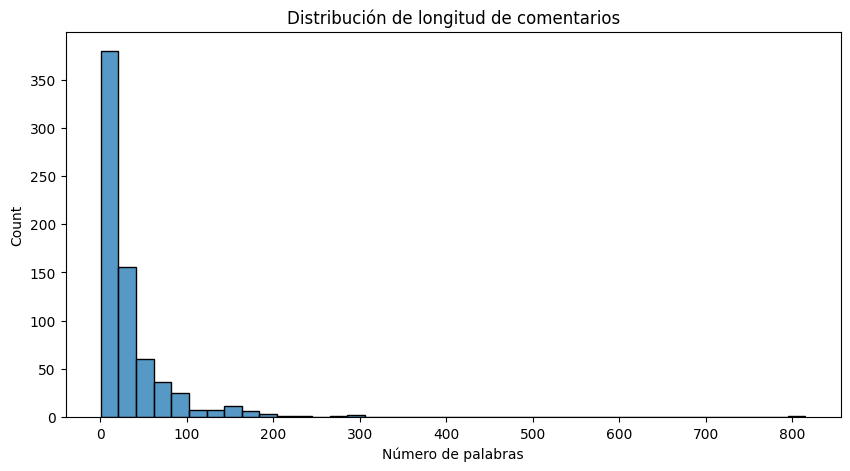

In [ ]:
train_lengths = X_train.str.split().apply(len)

print(train_lengths.describe())

plt.figure(figsize=(10, 5))

sns.histplot(train_lengths, bins=40)

plt.title("Distribución de longitud de comentarios")
plt.xlabel("Número de palabras")

plt.show()

## 5. Helper Functions

In [ ]:
def build_hf_dataset(X, y):

    df_local = pd.DataFrame({
        "text": X.values,
        "label": y.astype(int).values,
    })

    return Dataset.from_pandas(df_local)


def tokenize_dataset(dataset, tokenizer, max_len):

    def tokenize(batch):

        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=max_len,
        )

    dataset = dataset.map(tokenize, batched=True)

    dataset = dataset.remove_columns(["text"])

    dataset.set_format("torch")

    return dataset


def compute_metrics(eval_pred):

    logits, labels = eval_pred

    probs = torch.softmax(
        torch.tensor(logits),
        dim=1
    )[:, 1].numpy()

    preds = np.argmax(logits, axis=1)

    return {

        "accuracy": accuracy_score(labels, preds),

        "precision_toxic": precision_score(
            labels,
            preds,
            pos_label=1,
        ),

        "recall_toxic": recall_score(
            labels,
            preds,
            pos_label=1,
        ),

        "f1_toxic": f1_score(
            labels,
            preds,
            pos_label=1,
        ),

        "roc_auc": roc_auc_score(labels, probs),
    }


def evaluate_model(trainer, hf_test, y_test, model_name):

    pred_output = trainer.predict(hf_test)

    logits = pred_output.predictions

    probs = torch.softmax(
        torch.tensor(logits),
        dim=1
    )[:, 1].numpy()

    preds = np.argmax(logits, axis=1)

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(classification_report(
        y_test,
        preds,
        target_names=["No tóxico", "Tóxico"]
    ))

    cm = confusion_matrix(y_test, preds)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No tóxico", "Tóxico"],
        yticklabels=["No tóxico", "Tóxico"],
    )

    plt.title(f"{model_name} — Confusion Matrix")

    plt.xlabel("Predicción")
    plt.ylabel("Real")

    plt.savefig(PROJECT_ROOT / 'reports' / 'v2' / f"{model_name}_confusion.png",
            dpi=150, bbox_inches='tight')

    plt.show()

    return {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
        "preds": preds,
        "probs": probs,
    }

## 6. HuggingFace Dataset

In [ ]:
hf_train_raw = build_hf_dataset(X_train, y_train)
hf_valid_raw = build_hf_dataset(X_valid, y_valid)
hf_test_raw  = build_hf_dataset(X_test, y_test)

print(hf_train_raw)

Dataset({
    features: ['text', 'label'],
    num_rows: 699
})



# 7. Baseline — DistilBERT

DistilBERT será el baseline generalista.

Ventajas:
- más liviano
- rápido
- estable
- ideal para datasets pequeños


In [ ]:
DISTIL_MODEL = "distilbert-base-uncased"

MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 3
LR = 2e-5

print(DISTIL_MODEL)

distilbert-base-uncased


In [ ]:
distil_tokenizer = AutoTokenizer.from_pretrained(
    DISTIL_MODEL
)

distil_train = tokenize_dataset(
    hf_train_raw,
    distil_tokenizer,
    MAX_LEN,
)

distil_valid = tokenize_dataset(
    hf_valid_raw,
    distil_tokenizer,
    MAX_LEN,
)

distil_test = tokenize_dataset(
    hf_test_raw,
    distil_tokenizer,
    MAX_LEN,
)

Map: 100%|██████████| 150/150 [00:00<00:00, 10128.07 examples/s]


In [ ]:
distil_collator = DataCollatorWithPadding(tokenizer=distil_tokenizer)

distil_model = AutoModelForSequenceClassification.from_pretrained(
    DISTIL_MODEL,
    num_labels=2,
)

distil_model.to(device)

print(distil_model.__class__.__name__)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1192.80it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification


In [ ]:
distil_args = TrainingArguments(

    output_dir= PROJECT_ROOT / "models" / "distilbert_results",

    learning_rate=LR,

    num_train_epochs=EPOCHS,

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1_toxic",
    greater_is_better=True,

    warmup_ratio=0.1,

    logging_steps=10,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=RAND,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
distil_early_stopping = EarlyStoppingCallback(early_stopping_patience=2)

distil_trainer = Trainer(

    model=distil_model,

    args=distil_args,

    train_dataset=distil_train,
    eval_dataset=distil_valid,

    processing_class=distil_tokenizer,

    data_collator=distil_collator,

    compute_metrics=compute_metrics,

    callbacks=[distil_early_stopping],
)

In [ ]:
print("=" * 50)
print("TRAINING DISTILBERT")
print("=" * 50)

distil_trainer.train()

TRAINING DISTILBERT


Epoch,Training Loss,Validation Loss,Accuracy,Precision Toxic,Recall Toxic,F1 Toxic,Roc Auc
1,0.562122,0.536817,0.715232,0.721311,0.628571,0.671756,0.808818
2,0.417088,0.541987,0.754967,0.698795,0.828571,0.758170,0.833510
3,0.316711,0.569083,0.768212,0.753623,0.742857,0.748201,0.823986


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.22s/it]


TrainOutput(global_step=264, training_loss=0.44362344886317395, metrics={'train_runtime': 36.2928, 'train_samples_per_second': 57.78, 'train_steps_per_second': 7.274, 'total_flos': 54207108392208.0, 'train_loss': 0.44362344886317395, 'epoch': 3.0})

## 8. Evaluación — DistilBERT

DistilBERT
              precision    recall  f1-score   support

   No tóxico       0.82      0.72      0.76        81
      Tóxico       0.71      0.81      0.76        69

    accuracy                           0.76       150
   macro avg       0.76      0.76      0.76       150
weighted avg       0.77      0.76      0.76       150



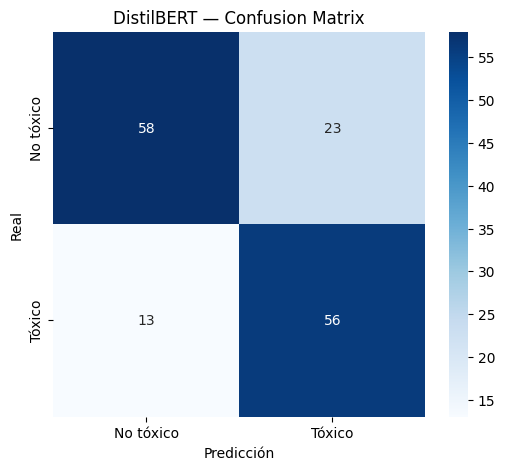

In [ ]:
distil_results = evaluate_model(
    distil_trainer,
    distil_test,
    y_test,
    "DistilBERT",
)


# 9. Fine-Tuning especializado — RoBERTa Hate

Modelo especializado en:
- hate speech
- toxicidad
- abuso online

Modelo:
cardiffnlp/twitter-roberta-base-hate


In [ ]:
HATE_MODEL = "cardiffnlp/twitter-roberta-base-hate"

MAX_LEN = 128
BATCH_SIZE = 8
EPOCHS = 3
LR = 2e-5

print(HATE_MODEL)

cardiffnlp/twitter-roberta-base-hate


In [ ]:
hate_tokenizer = AutoTokenizer.from_pretrained(
    HATE_MODEL
)

hate_train = tokenize_dataset(
    hf_train_raw,
    hate_tokenizer,
    MAX_LEN,
)

hate_valid = tokenize_dataset(
    hf_valid_raw,
    hate_tokenizer,
    MAX_LEN,
)

hate_test = tokenize_dataset(
    hf_test_raw,
    hate_tokenizer,
    MAX_LEN,
)

Map: 100%|██████████| 150/150 [00:00<00:00, 10121.39 examples/s]


In [ ]:
hate_collator = DataCollatorWithPadding(tokenizer=hate_tokenizer)

hate_model = AutoModelForSequenceClassification.from_pretrained(
    HATE_MODEL,
    num_labels=2,
    ignore_mismatched_sizes=True,
)

hate_model.to(device)

print(hate_model.__class__.__name__)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5778.78it/s]


RobertaForSequenceClassification


## 10. Fine-Tuning controlado

In [ ]:
# Congelar backbone

for param in hate_model.base_model.parameters():
    param.requires_grad = False

# Classification head entrenable
classifier_found = False

for name, param in hate_model.named_parameters():

    if "classifier" in name:

        param.requires_grad = True
        classifier_found = True

if classifier_found:
    print("Classification head desbloqueada")
else:
    print("⚠️ No se encontró classifier head")

# Verificación
total_params = 0
trainable_params = 0

for p in hate_model.parameters():

    total_params += p.numel()

    if p.requires_grad:
        trainable_params += p.numel()

pct = trainable_params / total_params * 100

print()
print(f"Trainable params: {trainable_params:,}")
print(f"Total params: {total_params:,}")
print(f"Trainable %: {pct:.2f}%")

Classification head desbloqueada

Trainable params: 592,130
Total params: 124,647,170
Trainable %: 0.48%


In [ ]:
hate_args = TrainingArguments(

    output_dir= PROJECT_ROOT / "models" / "roberta_hate_results",

    learning_rate=LR,

    num_train_epochs=EPOCHS,

    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1_toxic",
    greater_is_better=True,

    warmup_ratio=0.1,

    logging_steps=10,

    fp16=torch.cuda.is_available(),

    report_to="none",

    seed=RAND,
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
hate_early_stopping = EarlyStoppingCallback(early_stopping_patience=2)

hate_trainer = Trainer(

    model=hate_model,

    args=hate_args,

    train_dataset=hate_train,
    eval_dataset=hate_valid,

    processing_class=hate_tokenizer,

    data_collator=hate_collator,

    compute_metrics=compute_metrics,

    callbacks=[hate_early_stopping],
)

In [ ]:
print("=" * 50)
print("TRAINING ROBERTA HATE")
print("=" * 50)

hate_trainer.train()

TRAINING ROBERTA HATE


Epoch,Training Loss,Validation Loss,Accuracy,Precision Toxic,Recall Toxic,F1 Toxic,Roc Auc
1,0.613999,0.514029,0.721854,0.769231,0.571429,0.655738,0.844621
2,0.612199,0.497269,0.741722,0.792453,0.600000,0.682927,0.853704
3,0.556086,0.492456,0.741722,0.781818,0.614286,0.688000,0.856085


Writing model shards: 100%|██████████| 1/1 [00:06<00:00,  6.07s/it]


TrainOutput(global_step=264, training_loss=0.6079502448891149, metrics={'train_runtime': 35.1712, 'train_samples_per_second': 59.623, 'train_steps_per_second': 7.506, 'total_flos': 107744491058700.0, 'train_loss': 0.6079502448891149, 'epoch': 3.0})

## 11. Evaluación — RoBERTa Hate

RoBERTa Hate
              precision    recall  f1-score   support

   No tóxico       0.69      0.79      0.74        81
      Tóxico       0.70      0.58      0.63        69

    accuracy                           0.69       150
   macro avg       0.69      0.68      0.69       150
weighted avg       0.69      0.69      0.69       150



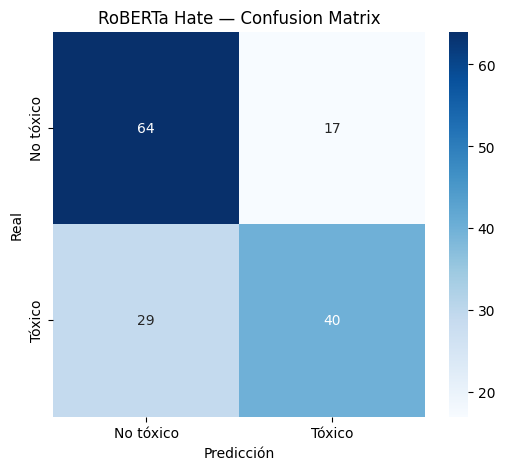

In [ ]:
hate_results = evaluate_model(
    hate_trainer,
    hate_test,
    y_test,
    "RoBERTa Hate",
)

## 12. Comparación de modelos

In [ ]:
comparison_df = pd.DataFrame({

    "Model": [
        "DistilBERT",
        "RoBERTa Hate",
    ],

    "Accuracy": [
        distil_results["accuracy"],
        hate_results["accuracy"],
    ],

    "Precision": [
        distil_results["precision"],
        hate_results["precision"],
    ],

    "Recall": [
        distil_results["recall"],
        hate_results["recall"],
    ],

    "F1": [
        distil_results["f1"],
        hate_results["f1"],
    ],

    "ROC-AUC": [
        distil_results["roc_auc"],
        hate_results["roc_auc"],
    ],
})

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,DistilBERT,0.760000,0.708861,0.811594,0.756757,0.865987
1,RoBERTa Hate,0.693333,0.701754,0.579710,0.634921,0.797370


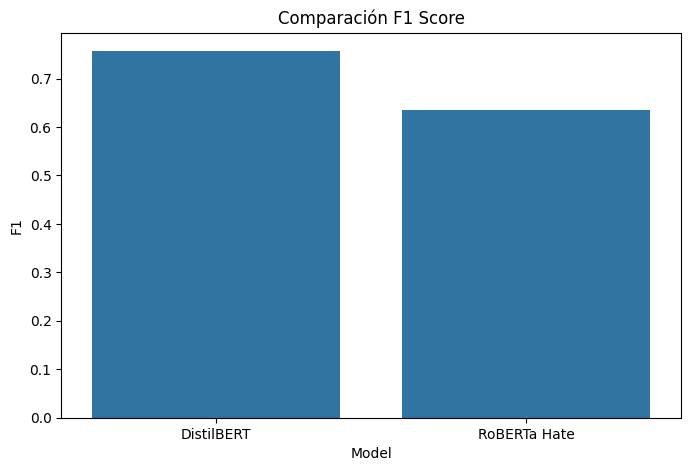

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="F1",
)

plt.title("Comparación F1 Score")
plt.show()

## 13. Error Analysis

In [ ]:
if hate_results["f1"] >= distil_results["f1"]:

    best_name = "RoBERTa Hate"
    best_preds = hate_results["preds"]
    best_probs = hate_results["probs"]

else:

    best_name = "DistilBERT"
    best_preds = distil_results["preds"]
    best_probs = distil_results["probs"]

print("Best model:", best_name)

Best model: DistilBERT


In [ ]:
error_df = pd.DataFrame({

    "text": X_test.values,
    "real": y_test.values,
    "pred": best_preds,
    "prob_toxic": best_probs,
})

error_df["is_error"] = (
    error_df["real"] != error_df["pred"]
)

print("Errores:", error_df["is_error"].sum())
error_df.head()

Errores: 36


,text,real,pred,prob_toxic,is_error
0,"So sad, he looked like such a nice young man",0,0,0.098947,False
1,peggy Hubbard for president,0,0,0.175114,False
2,"Thats a real parent, a real mother. Nothing bu...",0,1,0.875734,True
3,Lol stupid mooslims,1,1,0.884139,False
4,Another great video and thanks for not putting...,0,0,0.323487,False


In [ ]:
false_negatives = error_df[(error_df["real"] == 1) & (error_df["pred"] == 0)]

print("=" * 80)
print("FALSE NEGATIVES")
print("=" * 80)

for idx, row in false_negatives.head(10).iterrows():

    print("\nProb toxicidad:", round(row["prob_toxic"], 4))
    print("-" * 60)
    print(row["text"])


FALSE NEGATIVES

Prob toxicidad: 0.3945
------------------------------------------------------------
They are protecting and serving us, from people like Michael Brown. The guy deserved to be killed, cry more about it...

Prob toxicidad: 0.497
------------------------------------------------------------
So the autopsy showed a number of wounds to the right arm making the scenario of him being shot with his hands raised a lot less likely. Or are we still trying to claim that? Let's see, innocent unarmed gentle giant, minding his own business, gunned down in cold blood for jaywalking by a sadistic, jack-booted, racist thug of a police officer who shot the innocent youth in the back while his hands were raised trying to surrender. I keep forgetting which BS story we are still trying to defend and which claims have been totally refuted by the facts. Regardless, it "doesn't matter" because we have already decided that the cop is guilty.

Prob toxicidad: 0.2156
------------------------------

## 14. Guardado del mejor modelo

In [ ]:
SAVE_DIR = PROJECT_ROOT / "models"

if best_name == "RoBERTa Hate":

    final_model = hate_trainer
    final_tokenizer = hate_tokenizer

    save_path = SAVE_DIR / "best_roberta_hate"

else:

    final_model = distil_trainer
    final_tokenizer = distil_tokenizer

    save_path = SAVE_DIR / "best_distilbert"

final_model.save_model(save_path)
final_tokenizer.save_pretrained(save_path)
print("Modelo guardado en:", save_path)

Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.58s/it]

Modelo guardado en: /mnt/c/Users/under/Documents/F5/3_Projects/Project_9_Equipo3/Project_YT/models/best_distilbert
